# Week 6 - Drivers of glacial-interglacial cycles

We have talked about how 20,000 years ago during the Last Glacial Maximum, much of North America has covered by a thick ice sheet:

<img src="./figures/ice_sheets_2x.png" width = 600>


<img src="./figures/LGM_Modern_ice.png" width = 600>

We have looked at ice core data that shows that CO$_2$ has varied through time:

<img src="./figures/ice_core_co2.png" width = 600>

**What sets the timing of these glacial-interglacial cycles?**

## Earth's orbit - pacemaker of the Ice Ages

*material in this section of the notebook is modified from materials of Lisa Tauxe's Python for Earth Science Students course: https://github.com/ltauxe/Python-for-Earth-Science-Students*

In 1920, Milutin Milankovitz  explained the coming and going of ice ages as a response to changes in the Earth's _insolation_ (the amount of energy recieved from the sun). He argued that insolation is controlled by changes in the Earth's orbit around the sun.  This idea has now been widely embraced by the paleoclimate community, largely because of the very strong coherence between  cycles in Earth's orbit and evidence for changes in ice volume using geochemical proxies like oxygen isotopes —— data we will look at today.  

The orbital cycles are influenced by gravity of the Moon, Sun, Jupiter, and Saturn and can be calculated knowing their orbital parameters.  Milankovitch famously took the first stab at it from his prison cell during WWI. Nowadays it is calculated with supercomputers.  The key parameters: **eccentricity**, **obliquity**, and **precession**.  

**Eccentricity** refers to the shape of Earth's orbit around the Sun. It varies between nearly circular (low eccentricity) and more elliptical (high eccentricity) over a period of approximately 100,000 years. Although eccentricity itself does not cause significant changes in the total amount of solar radiation (insolation) received by Earth, it modulates the influence of the other two orbital parameters, obliquity and precession.

**Obliquity** is the tilt of Earth's axis relative to its orbital plane. It changes between 22.1° and 24.5° over a period of about 41,000 years. Obliquity has a direct impact on insolation, as it determines the seasonal distribution of solar radiation at different latitudes. Higher obliquity generally leads to more pronounced seasons, with warmer summers and colder winters.

**Precession** is the wobble of Earth's axis, which causes the timing of the solstices and equinoxes to change relative to Earth's position in its orbit. It has a period of approximately 19,000 to 23,000 years. Precession affects the seasonal contrast between hemispheres, making one hemisphere's summer more intense while the other hemisphere experiences a milder summer.

<img src="./figures/Milankovitch_Cycles.jpg" width = 600>

[_Figure from_ http://www.jamstec.go.jp/e/about/press_release/20141027/; _see also_ http://www.sciencecourseware.org/eec/GlobalWarming/Tutorials/Milankovitch/].  

The Earth's orbital parameters of ellipticity, obliquity and precession vary in predictable ways.  One commonly used model for variations in them over the last few hundred million years was published by Laskar et al. (2004; http://dx.doi.org/10.1051/0004-6361:20041335).  

> This solution has been improved...by using a direct integration of the gravitational equations for the orbital motion, and by improving the dissipative contributions, in particular in the evolution of the Earth–Moon System. The orbital solution has been used for the calibration of the Neogene period (Lourens et al.  [CITE]), and is expected to be used for age calibrations of paleoclimatic data over 40 to 50 Myr, eventually over the full Palaeogene period (65 Myr) with caution. Beyond this time span, the chaotic evolution of the orbits prevents a precise determination of the Earth's motion. However, the most regular components of the orbital solution could still be used over a much longer time span. - Laskar et al. (2004)

Let's take a look for the behavior of the last few million years using the data file from the Laskar et al. (2004) paper. 

## Import the scientific python packages we will need

In [1]:
from cProfile import label

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.ma.core import shape

## Exercise 1 - Orbital variations and incoming insolation 

Import the Lasker orbital solution

In [2]:
orbital_cycles = pd.read_csv('./data/INSOLN.LA2004.BTL.100.csv')
orbital_cycles.head()

,Age (ka),Eccentricity,Obliquity,Precession
0,0,0.016702,0.409093,1.796257
1,1,0.017161,0.411353,1.497928
2,2,0.017497,0.413555,1.200024
3,3,0.017846,0.415639,0.903494
4,4,0.018211,0.417555,0.611381


**Code for you to write**

Define a variable called `orbital_cycles_1Myr` that is filtered to only have data for the past 1 million years (1000 ka). Plot this filtered dataset with Age vs the Eccentricity, Obliquity, and Precession values (i.e., create 3 subplots one for each of the orbital parameters)

(5 points)

In [3]:
orbital_cycles_1Myr = orbital_cycles[orbital_cycles['Age (ka)'] <= 1000]

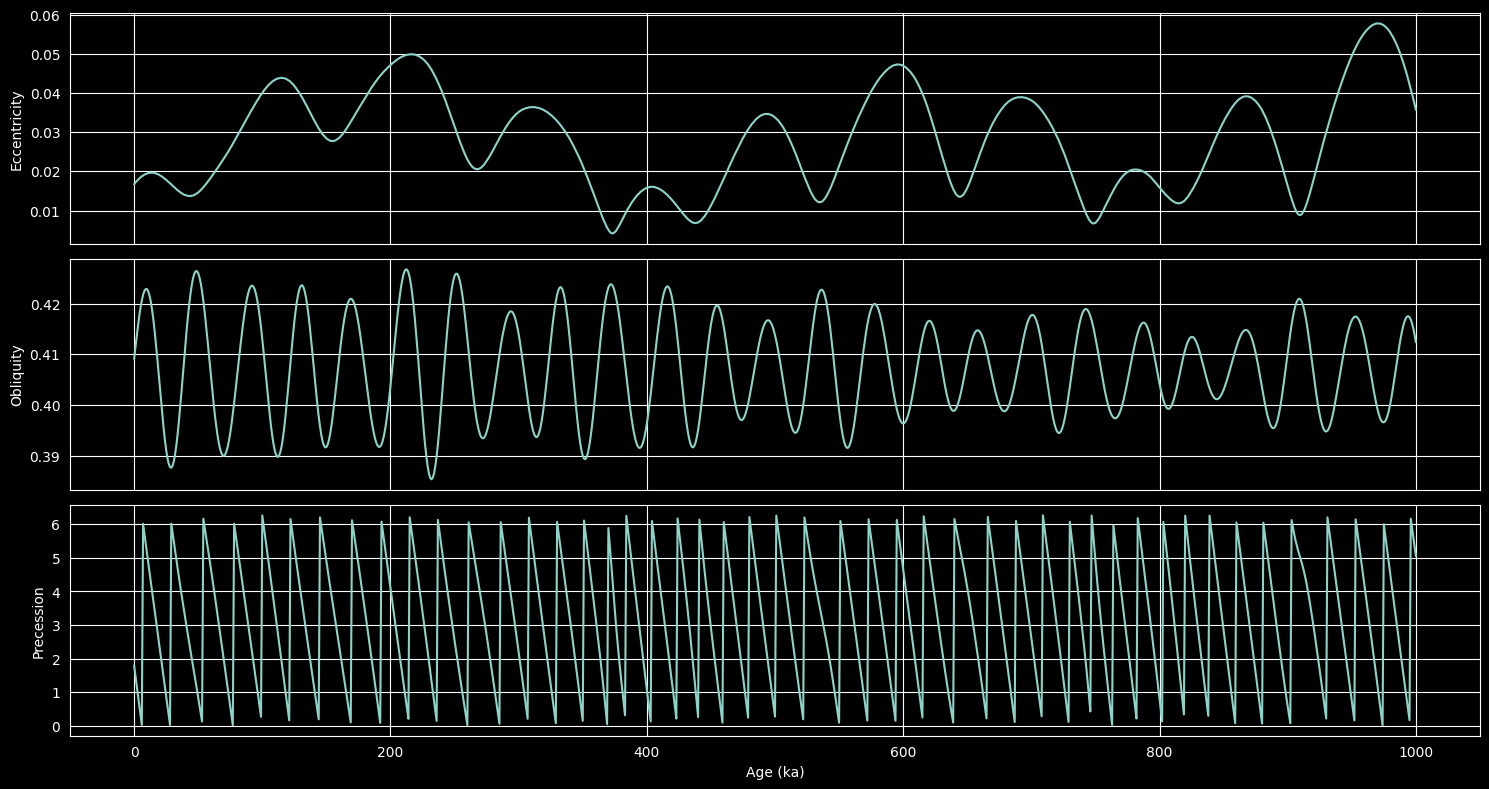

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

axes[0].plot(orbital_cycles_1Myr['Age (ka)'], orbital_cycles_1Myr['Eccentricity'])
axes[1].plot(orbital_cycles_1Myr['Age (ka)'], orbital_cycles_1Myr['Obliquity'])
axes[2].plot(orbital_cycles_1Myr['Age (ka)'], orbital_cycles_1Myr['Precession'])

axes[0].set_ylabel('Eccentricity')
axes[1].set_ylabel('Obliquity')
axes[2].set_ylabel('Precession')
axes[2].set_xlabel('Age (ka)')

plt.tight_layout()
plt.show()

### Relating these cycles to incoming insolation

You can see a lot of cycles on different time scales. The question is how this relates to the amount of insolation.  In the literature, there are many attempts to convert the orbital parameters, like those in the plot above, to the amount of insolation received by the Earth's atmosphere as a function of latitude and age. You can get such estimates here: https://www.ncdc.noaa.gov/paleo-search/study/5792 associated with this paper (Huybers, P. 2006, http://www.sciencemag.org/cgi/content/full/313/5786/508).  

It is traditional to consider the amount of insolation received at 65$^{\circ}$N.  So let's take a look (here we're loading the average insolation at 65 degrees N on the 21st of June each year).

In [5]:
insolation = pd.read_csv('./data/j_65north_new.csv')
insolation.tail()

,Age (ka),Insolation (W/m^2)
4996,4996,462.974623
4997,4997,458.902929
4998,4998,456.204162
4999,4999,455.042112
5000,5000,455.498717


**Code for you to write**

Make a plot using `plt.plot` of the insolation curve. Use `plt.xlim()` to make it so that time is limited and goes from 1000 ka to 0 ka (1,000 thousand years ago [same as 1 million] to present-day).

(5 points)

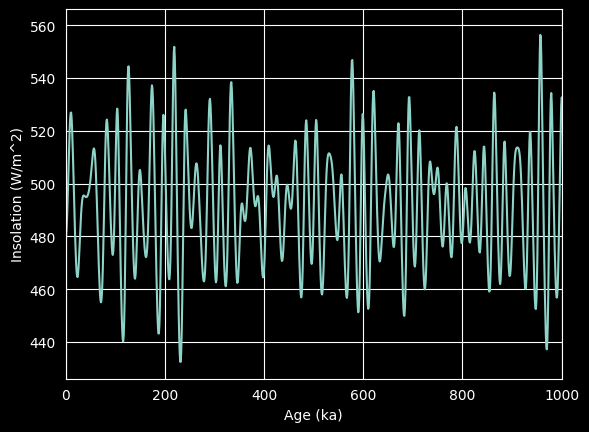

In [6]:
plt.figure()

plt.plot(insolation['Age (ka)'], insolation['Insolation (W/m^2)'])

plt.xlim(0,1000)
plt.xlabel('Age (ka)')
plt.ylabel('Insolation (W/m^2)')

plt.show()

### How big are these insolation changes?

These changes in insolation are interpretted to be important in driving glacial-interglacial cycles. How big are the changes in insolation?
*Calculate the mean insolation from data (`np.mean()` could help) and the maximum insolation from the data (`np.max()` could help. Then use these values to calculate the percentage difference between the maximum insolation and the mean. Do the same between the maximum and the minimum.* 

(10 points)

**Does this change seem like a big change sufficient to drive glacial-interglacial cycles?**

In [7]:
insolation_mean = np.mean(insolation['Insolation (W/m^2)'])

In [8]:
insolation_max = np.max(insolation['Insolation (W/m^2)'])

In [9]:
insolation_min = np.min(insolation['Insolation (W/m^2)'])

In [10]:
print(f'the percentage difference between the maximum insolation and the mean: {(insolation_max - insolation_mean) / insolation_mean:.2%}')

the percentage difference between the maximum insolation and the mean: 13.81%


In [11]:
print(f'the percentage difference between the maximum insolation and the minimum: {(insolation_max - insolation_min) / insolation_mean:.2%}')

the percentage difference between the maximum insolation and the minimum: 25.88%


Yes, this change seems like a big change sufficient to drive glacial-interglacial cycles.

## Exercise 2 - Comparisons to natural datasets 

### Let's have a look at the ice core CO$_2$ data. 

In [12]:
ice_core_co2 = pd.read_csv('./data/antarctica2015co2composite.txt',header=137,sep='\t')
ice_core_co2['age_ka'] = ice_core_co2['age_gas_calBP']/1000
ice_core_co2.tail()

,age_gas_calBP,co2_ppm,co2_1s_ppm,age_ka
1896,803925.28,202.92,2.06,803.92528
1897,804009.87,207.50,0.92,804.00987
1898,804522.67,204.86,1.64,804.52267
1899,805132.44,202.23,0.69,805.13244
1900,805668.87,207.29,2.20,805.66887


To analyze these data, we need to have an evenly spaced timeseries. We can use the scipy interpolation capabilities to do so. Here is an simple example from the scipy documentation:

SciPy (Scientific Python) is a powerful open-source library in Python, primarily used for scientific computing and technical computing. It builds on NumPy to provide a wide range of functionalities, including:

- Optimization: Tools for finding minima, maxima, and roots of functions.
- Integration: Numerical integration (e.g., quadrature and differential equation solvers).
- Linear Algebra: Advanced matrix computations and operations.
- Statistics: Statistical functions and probability distributions.
- Signal Processing: Tools for filtering, spectral analysis, and Fourier transforms.
- Image Processing: Basic image manipulation and analysis functions.
- Special Functions: Functions like Bessel, gamma, and others.

SciPy is widely used in fields like data science, engineering, physics, and machine learning. It offers high-performance, easy-to-use algorithms and is a cornerstone of the Python scientific computing ecosystem.

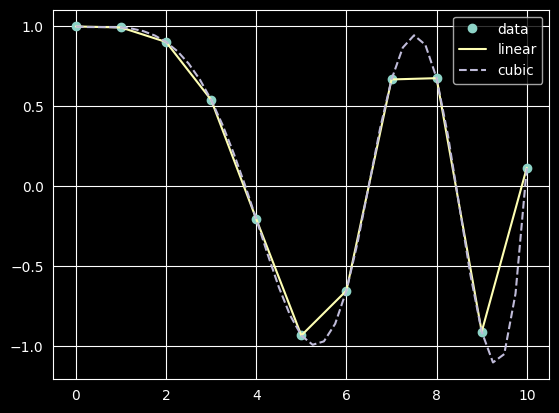

In [13]:
from scipy.interpolate import interp1d

x = np.linspace(0, 10, num=11, endpoint=True)
y = np.cos(-x**2/9.0)
f = interp1d(x, y)
f2 = interp1d(x, y, kind='cubic')

xnew = np.linspace(0, 10, num=41, endpoint=True)
plt.plot(x, y, 'o')
plt.plot(xnew, f(xnew), '-')
plt.plot(xnew, f2(xnew), '--')
plt.legend(['data', 'linear', 'cubic'], loc='best')
plt.show()

We can apply such an interpolation to the ice core data and resample it a evenly spaced 1 kyr intervals:

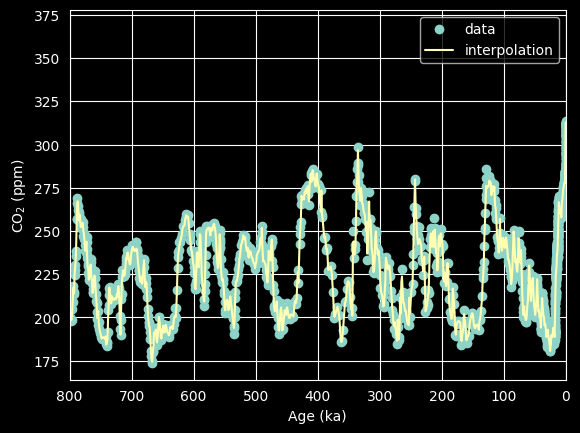

In [14]:
ice_interp = interp1d(ice_core_co2['age_ka'], ice_core_co2['co2_ppm'], kind='linear')

xnew = np.linspace(0, 800,num=801,endpoint=True)
co2_interp = ice_interp(xnew)
plt.plot(ice_core_co2['age_ka'],ice_core_co2['co2_ppm'], 'o', label = 'data')
plt.plot(xnew, co2_interp, '-',label='interpolation')
plt.legend()
plt.xlim(800,0)
plt.xlabel('Age (ka)')
plt.ylabel('CO$_2$ (ppm)')
plt.show()

Create a 2 by 1 plot (subplots) with the CO2 timeseries on the top plot and the insolation on the bottom plot. Does the signal match with the insolation signal?

(10 points)

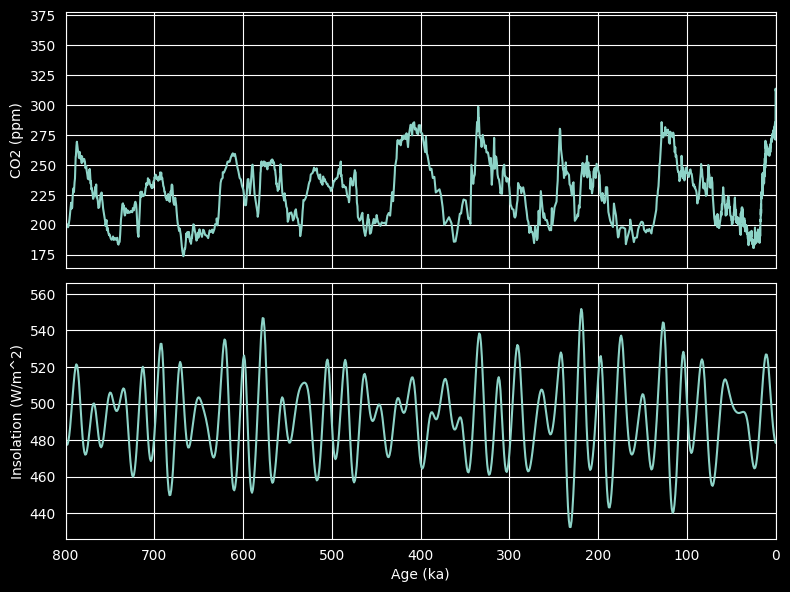

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(ice_core_co2['age_ka'], ice_core_co2['co2_ppm'])
axes[1].plot(insolation['Age (ka)'], insolation['Insolation (W/m^2)'])

axes[0].set_ylabel('CO2 (ppm)')
axes[1].set_ylabel('Insolation (W/m^2)')
axes[1].set_xlabel('Age (ka)')

plt.xlim(800, 0)
plt.tight_layout()
plt.show()

## Exercise 3 - Spectral analysis

Both insolation and the CO$_2$ records have a lot of wiggles over the last million years, but are the wiggles related to each other?  One way to look at this is using _time series analysis_.   There are entire courses devoted to this subject and a complete treatment is beyond the scope of this class, but we can begin to answer the basic question: *Do the two data sets have wiggles with the same frequencies?*

The analysis boils down to this: 

- According to Fourier, any periodic function $f(t)$ can be represented as the sum of a series of sines and cosines:   

$$f(t)=a_0+ \sum_{r=1}^\infty \bigr[a_r    \cos  \bigr( { {2\pi r}\over{T}}   t\bigr)  + b_r    \sin  \bigr( { {2\pi r}\over{T}}   t\bigl) \bigl]  $$

- You can represent data as a series in time (in the time-domain) as we have been doing OR you can represent the data in terms of frequency, looking for the _power_ in the data as a function of frequency.  This is known as the _power spectrum_. 

Let us take advantage of a **signal.periodogram** function in the **scipy** package.  That module has functions that allow us to  calculate the _power spectral density_ for a time series.  As a result we will be able to generate a _periodogram_, which is a plot of power versus frequency. 

We will also use a _window_ in the periodogram calculation.  What a _window_ does is multiply the time series by a function (called a taper) that weights information, suppressing data at the edges of the window and focussing on the center of the window. This step is necessary as otherwise there are artifacts that are introduced particularly given the finite nature of the data (i.e. that the signal starts and ends).  The simplest window is a _box car_ which gives equal weight to everything inside the window.  In the following, we will use a Hann window_ which looks more like a bell curve. The Hann window is a popular choice for general-purpose spectral analysis as it provides a good balance between frequency resolution and spectral leakage reduction. You can check it out here: https://en.wikipedia.org/wiki/Window_function

**What is the dominant signal in the ice sheet CO$_2$ data?**

In [16]:
from scipy import signal

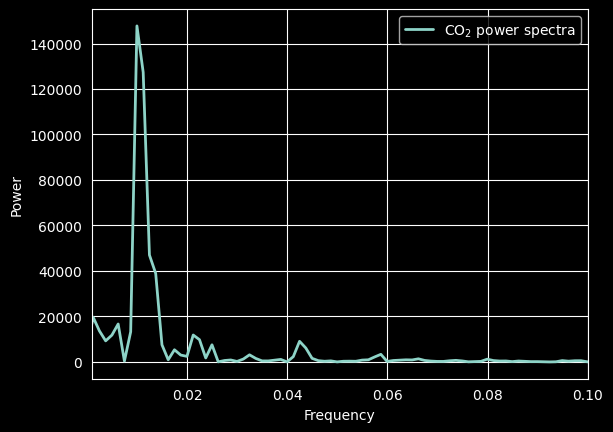

In [17]:
co2_freqs,co2_power = signal.periodogram(co2_interp,window='hann')

plt.plot(co2_freqs,co2_power,label='CO$_2$ power spectra',linewidth=2)

plt.xlim(.001,.1)

plt.xlabel('Frequency')
plt.ylabel('Power') 
plt.legend()
plt.show()

What does this dominant peak correspond to?

We know that eccentricity is supposed to have a dominant period at 100 kyr, obliquity at 41 kyr and precession at 23 and 19 kyr. Remember that these numbers are expressed in terms of the period, which is the inverse of the frequency so the frequency of them with be the inverse of the period

In [18]:
eccentricity_frequency = 1.0/100.0
obliquity_frequency = 1.0/41.0
precession_frequency19 = 1.0/19.0
precession_frequency22 = 1.0/22.5
precession_frequency24 = 1.0/23.8

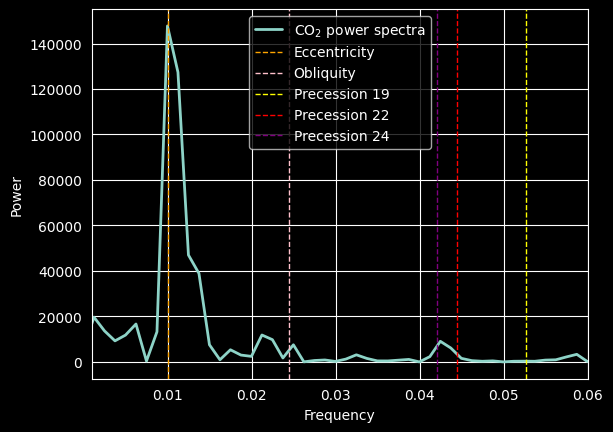

In [41]:
plt.plot(co2_freqs,co2_power,label='CO$_2$ power spectra',linewidth=2)
plt.axvline(x=eccentricity_frequency,label='Eccentricity',linewidth=1,linestyle='--', color="orange")
plt.axvline(x=obliquity_frequency,label='Obliquity',linewidth=1,linestyle='--', color="pink")
plt.axvline(x=precession_frequency19,label='Precession 19',linewidth=1,linestyle='--', color="yellow")
plt.axvline(x=precession_frequency22,label='Precession 22',linewidth=1,linestyle='--', color="red")
plt.axvline(x=precession_frequency24,label='Precession 24',linewidth=1,linestyle='--', color="purple")
plt.xlim(.001,.06)

plt.xlabel('Frequency')
plt.ylabel('Power') 
plt.legend()
plt.show()

## The dominant signal of ice sheet CO$_2$ data is Eccentlicity.

## What is the dominant periodic signal in the insolation curve?

Take the same approach above and use the `signal.periodogram()` function to calculate the power spectral density of the 65$^{\circ}$N insolation curve.

(10 points)

In [21]:
signal.periodogram(insolation['Insolation (W/m^2)'])

(array([0.00000000e+00, 1.99960008e-04, 3.99920016e-04, ...,
        4.99500100e-01, 4.99700060e-01, 4.99900020e-01], shape=(2501,)),
 array([1.58256865e-23, 1.09905968e+01, 1.23065043e+02, ...,
        4.65749763e-02, 4.75959778e-02, 5.08028369e-02], shape=(2501,)))

In [22]:
np.shape(signal.periodogram(insolation['Insolation (W/m^2)']))

(2, 2501)

Plot the periodogram and plot the eccentricity and obliquity lines as well.

(10 points)

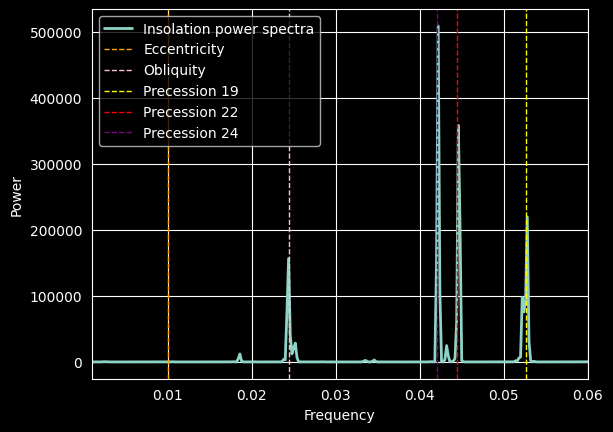

In [39]:
plt.figure()
insolation_freqs,insolation_power = signal.periodogram(insolation['Insolation (W/m^2)'],window='hann')


plt.plot(insolation_freqs,insolation_power,label='Insolation power spectra',linewidth=2)
plt.axvline(x=eccentricity_frequency,label='Eccentricity',linewidth=1,linestyle='--', color="orange")
plt.axvline(x=obliquity_frequency,label='Obliquity',linewidth=1,linestyle='--', color="pink")
plt.axvline(x=precession_frequency19,label='Precession 19',linewidth=1,linestyle='--', color="yellow")
plt.axvline(x=precession_frequency22,label='Precession 22',linewidth=1,linestyle='--', color="red")
plt.axvline(x=precession_frequency24,label='Precession 24',linewidth=1,linestyle='--', color="purple")

plt.xlim(.001,.06)

plt.xlabel('Frequency')
plt.ylabel('Power')
plt.legend(loc='upper left')
plt.show()

What is the dominant signal in the 65ºN insolation curve and how does it compare to dominant period in the ice sheet CO$_2$ data?

(10 points)

The dominant signals of 65ºN insolation are obliquity and precession, which is different from the ice sheet CO$_2$ data dominated by eccentricity.

## Exercise 4 - Longer timescale paleoclimate records

The ice core record is a very impressive one, but unfortunately, it only goes back ~800,000 years. While these seems like a long time, it is only 0.02% of the history of the Earth.

### Oxygen isotopes

One way that we can go further back with a paleoclimate record is using marine fossils such as foraminifera. Foraminifera are made of calcium carbonate: $CaCO_3$

The oxygen isotopes $^{16}O$ vs $^{18}O$ in the $CaCO_3$ forms a record of both temperature and ice volume. $\delta^{18}O$ is a way to express the ratio between $^{16}O$ and $^{18}O$. 

$$ \delta^{18}O = \left( \frac{\left( \frac{^{18}O}{^{16}O} \right)_{\text{sample}}}{\left( \frac{^{18}O}{^{16}O} \right)_{\text{standard}}} - 1 \right) \times 1000 \ ^{o}\!/\!_{oo} $$


When water is warm, the $\delta ^{{18}}O$ of the fossils is low and when water is cold $\delta ^{{18}}O$ is higher. There is a similar relationship with ice volume: when there is less ice the $\delta ^{{18}}O$ of water is lower and there is more ice is cold $\delta ^{{18}}O$ of water is higher which ends up contributing to the value of the fossil foraminifera.

So higher $\delta^{18}O$ values are associated with a colder planet and lower $\delta^{18}O$ values with a warmer planet.

A compilation of these data was published by Lisecki and Raymo (2005, http://dx.doi.org/10.1029/2004PA001071) called the LR04 stack.  This is a stack of 58 records of oxygen isotopic variations, several of which were independently dated using magnetostratigraphy, from all over the world's oceans.   

Let's import the data and take a look at the record: 

In [44]:
LR04_d18O = pd.read_csv('./data/LR04stack.csv')
print(LR04_d18O.tail())

      Age (ka)  d18O  uncertainty
2110    5300.0  2.91         0.06
2111    5305.0  2.79         0.04
2112    5310.0  2.79         0.09
2113    5315.0  2.84         0.07
2114    5320.0  2.91         0.09


-->data is per 5 ka in the end of the data set!!

Plot the $\delta ^{18}O$ record against age. Remember to label the axes

(10 points)

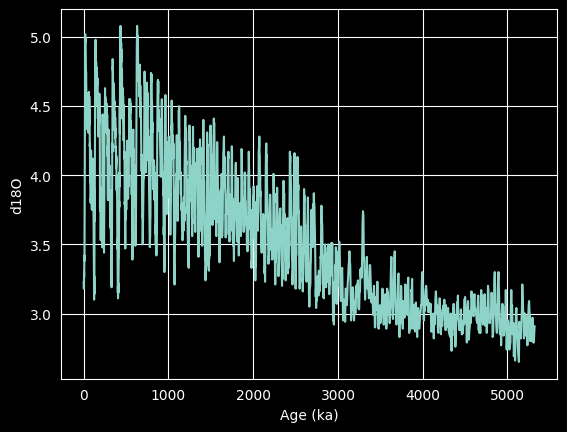

In [42]:
plt.figure()
plt.plot(LR04_d18O["Age (ka)"], LR04_d18O["d18O"], label='LR04')
plt.xlabel('Age (ka)')
plt.ylabel('d18O')
plt.show()

Do the same signal analysis as above in order to analyze the power spectra. What is the dominant frequency, which orbital variation does this correspond to?

(15 points)

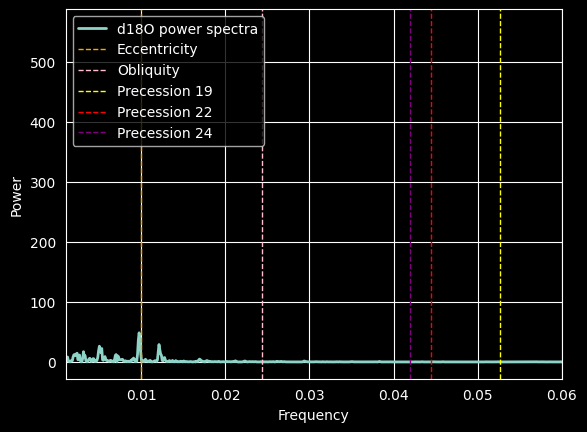

In [45]:
plt.figure()
d18O_freqs,d18O_power = signal.periodogram(LR04_d18O["d18O"], fs=1/5, window='hann')


plt.plot(d18O_freqs,d18O_power,label='d18O power spectra',linewidth=2)
plt.axvline(x=eccentricity_frequency,label='Eccentricity',linewidth=1,linestyle='--', color="orange")
plt.axvline(x=obliquity_frequency,label='Obliquity',linewidth=1,linestyle='--', color="pink")
plt.axvline(x=precession_frequency19,label='Precession 19',linewidth=1,linestyle='--', color="yellow")
plt.axvline(x=precession_frequency22,label='Precession 22',linewidth=1,linestyle='--', color="red")
plt.axvline(x=precession_frequency24,label='Precession 24',linewidth=1,linestyle='--', color="purple")
plt.xlim(.001,.06)

plt.xlabel('Frequency')
plt.ylabel('Power')
plt.legend(loc='upper left')
plt.show()

The dominant frequency of d18O is at around 0.01, which corresponds to eccentricity.


**Whether a glacier/ice sheet grows is controlled by a combination of the extent of snowfall during winter (growth) and the extent of melting/calving during summer (ablation). Using this information, explain why we often assess solar variations as the amount of summer insolation received at 65 degrees North.**

(10 points)

Since the 65 degrees North gets maximum amount of insolation on the Earth (since the Earth tilts by 23.4 degrees), it is a good measurement of solar variations.

## Bonus

How can we determine that a spectral peak is significant and not just the result of noise in the data?

Let's take this approach:

1. **Fit an AR1 (Autoregressive order 1) model to the CO2 data (`co2_interp`)**:
An AR1 model is a simple time series model that assumes that the value at time t depends linearly on the value at time t-1 and some noise. It is often used to model "red noise" or "autocorrelated noise" that is common in many natural time series like climate data.

2. **Generate synthetic red noise time series**:
We generate a large number (`n_synthetic = 1000`) of synthetic time series using the AR1 model parameters estimated from the CO2 data. Each synthetic time series has the same length (n_samples) as the CO2 data. By generating these synthetic time series, we create a set of surrogate data with similar statistical properties to the original CO2 data but without any real-world signal.

3. **Compute the power spectra of the synthetic time series**:
For each synthetic time series, we calculate the power spectrum using the periodogram method with a Hann window. This gives us an estimate of the power at different frequencies in each synthetic time series. We store these power spectra in a 2D array, synthetic_power_spectra.

4. **Calculate the 95th percentile of the synthetic power spectra**:
Compute the 95th percentile power spectrum across all the synthetic time series. This spectrum represents the threshold above which we can consider a peak in the CO2 power spectrum as significant (with a 95% confidence level).

5. **Compute the periodogram of the CO2 data (`co2_interp`)**:
Calculate the power spectrum of the CO2 data using the periodogram method with a Hann window. This gives us an estimate of the power at different frequencies in the CO2 data.

6. **Plot the power spectra and the significant peaks**:
Plot the power spectra of the CO2 data along with the 95th percentile threshold calculated from the synthetic power spectra. Any peaks in the CO2 power spectrum that rise above the 95th percentile threshold can be considered significant, meaning that they are unlikely to have occurred due to random fluctuations (red noise) alone.

Following this approach, we can evaluate our confidence in interpreting the power spectra in the CO2 data. We can identify significant peaks in the power spectrum that are likely to be genuine features of the data rather than artifacts of random fluctuations or noise.

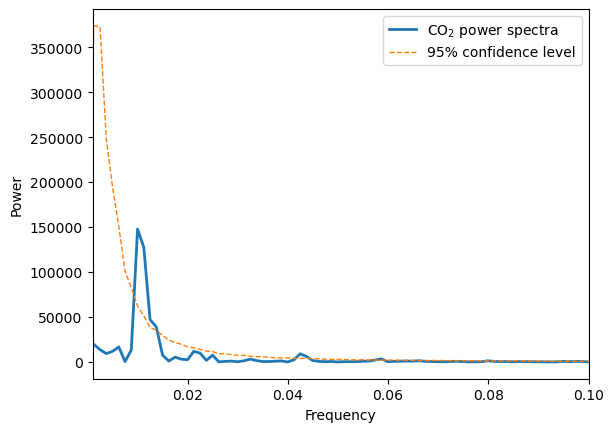

In [71]:
import numpy as np
from scipy.stats import chi2
from statsmodels.tsa.arima.model import ARIMA
from scipy.signal import periodogram

# Fit an AR1 model to the co2_interp data
ar1_model = ARIMA(co2_interp, order=(1, 0, 0)).fit()

# Generate a large number of synthetic red noise time series
n_synthetic = 1000
n_samples = len(co2_interp)
phi = ar1_model.params[1]
residuals = ar1_model.resid
residual_variance = np.var(residuals)
white_noise_std = np.sqrt(residual_variance)

synthetic_power_spectra = np.zeros((n_synthetic, n_samples // 2))
for i in range(n_synthetic):
    red_noise = np.zeros(n_samples)
    red_noise[0] = np.random.normal(loc=0, scale=white_noise_std)
    for t in range(1, n_samples):
        red_noise[t] = phi * red_noise[t - 1] + np.random.normal(loc=0, scale=white_noise_std)
    
    red_noise_freqs, synthetic_power_spectrum = periodogram(red_noise, window='hann')
    synthetic_power_spectra[i, :] = synthetic_power_spectrum[:n_samples // 2]

# Compute the 95th percentile of the synthetic power spectra
threshold_power_spectrum = np.percentile(synthetic_power_spectra, 95, axis=0)

# Compute the periodogram for co2_interp data
co2_freqs, co2_power = periodogram(co2_interp, window='hann')

# Make sure the lengths of co2_freqs and threshold_power_spectrum are the same
co2_freqs = co2_freqs[:len(threshold_power_spectrum)]

# Plot the power spectra and the significant peaks
plt.plot(co2_freqs, co2_power[:len(threshold_power_spectrum)], label='CO$_2$ power spectra', linewidth=2)
plt.plot(co2_freqs, threshold_power_spectrum, label='95% confidence level', linestyle='--', linewidth=1)

plt.xlim(.001, .1)
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.legend()
plt.show()